In [ ]:
import sys, platform, hashlib, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
print(f"Python: {sys.version.split()[0]} | Platform: {platform.platform()}")

Python: 3.12.13 | Platform: Linux-6.6.122+-x86_64-with-glibc2.35


In [ ]:
CSV_YOLU = "Telco-Customer-Churn.csv"
HEDEF    = "Churn"

def file_hash(path):
    return hashlib.md5(open(path, "rb").read()).hexdigest()

if CSV_YOLU:
    df = pd.read_csv(CSV_YOLU).copy()
    print(f"Veri: {CSV_YOLU} setinden yararlanıldı. ")
    assert HEDEF in df.columns, f"'{HEDEF}' sütunu bulunamadı: {list(df.columns)}"
else:
    from sklearn.datasets import load_breast_cancer
    df = load_breast_cancer(as_frame=True).frame.copy()
    HEDEF = "target"
    print("Uyarı: CSV verilmedi; örnek bir veri seti  kullanılıyor.")

print(f"Gözlem sayısı: {len(df)} | Değişken sayısı: {df.shape[1]}")

Veri: Telco-Customer-Churn.csv setinden yararlanıldı. 
Gözlem sayısı: 7043 | Değişken sayısı: 21


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [ ]:
print("Eksik değer toplamı:", df.isnull().sum().sum())

Eksik değer toplamı: 0



Sınıf dağılımı:
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


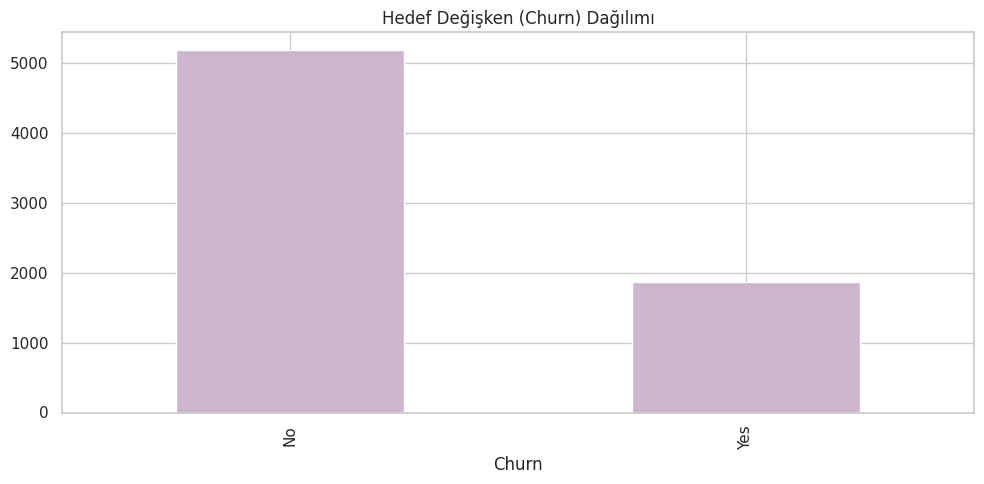

In [ ]:
dagilim = df[HEDEF].value_counts(normalize=True)
print("\nSınıf dağılımı:")
print(dagilim.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
df[HEDEF].value_counts().plot(kind="bar", color="#cdb5cd", ax=ax)
ax.set_title("Hedef Değişken (Churn) Dağılımı"); ax.set_xlabel(HEDEF);
plt.tight_layout(); plt.show()

if dagilim.min() < 0.20:
    print("UYARI: Sınıf dengesizliği var; class_weight='balanced' kullanılacak.")
if len(df) < 30:
    print("UYARI: Küçük örneklem (n<30) — güç analizi yapıldı mı?")

In [ ]:
for col in df.columns:
    if df[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

y = df[HEDEF]
X = pd.get_dummies(df.drop(columns=[HEDEF]), drop_first=True)

if not pd.api.types.is_numeric_dtype(y):
    y = pd.Series(LabelEncoder().fit_transform(y), name=HEDEF)
    print("Hedef değişken sayısal olarak kodlandı.")

Hedef değişken sayısal olarak kodlandı.


In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print(f"Eğitim seti: {len(X_tr)} | Test seti: {len(X_te)}")

Eğitim seti: 5282 | Test seti: 1761


In [ ]:
def degerlendir(model, ad):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    cv_skor = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="accuracy")

    m = {
        "Model": ad,
        "Doğruluk (Accuracy)": accuracy_score(y_te, y_pred),
        "Kesinlik (Precision)": precision_score(y_te, y_pred, average="weighted", zero_division=0),
        "Duyarlılık (Recall)": recall_score(y_te, y_pred, average="weighted"),
        "F1 Skoru": f1_score(y_te, y_pred, average="weighted"),
        "CV Ortalama": cv_skor.mean(),
        "CV Std": cv_skor.std(),
    }
    if len(np.unique(y_tr)) == 2:
        m["ROC-AUC"] = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

    print(f"--- {ad} ---")
    print(classification_report(y_te, y_pred, zero_division=0))
    return model, y_pred, m

dt_model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                                  class_weight="balanced", random_state=SEED)
rf_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                  class_weight="balanced", n_jobs=-1, random_state=SEED)

dt, dt_pred, dt_m = degerlendir(dt_model, "Decision Tree")
rf, rf_pred, rf_m = degerlendir(rf_model, "Random Forest")

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.81      1294
           1       0.52      0.76      0.62       467

    accuracy                           0.75      1761
   macro avg       0.71      0.75      0.72      1761
weighted avg       0.80      0.75      0.76      1761

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.93      0.49      0.64      1294
           1       0.39      0.91      0.54       467

    accuracy                           0.60      1761
   macro avg       0.66      0.70      0.59      1761
weighted avg       0.79      0.60      0.62      1761



In [ ]:
tablo = pd.DataFrame([dt_m, rf_m]).set_index("Model").round(4)
tablo.to_csv("model_karsilastirma.csv")
tablo

,Doğruluk (Accuracy),Kesinlik (Precision),Duyarlılık (Recall),F1 Skoru,CV Ortalama,CV Std,ROC-AUC
Model,,,,,,,
Decision Tree,0.7501,0.7968,0.7501,0.7623,0.7234,0.0154,0.8272
Random Forest,0.5985,0.7902,0.5985,0.6154,0.6882,0.0175,0.8112


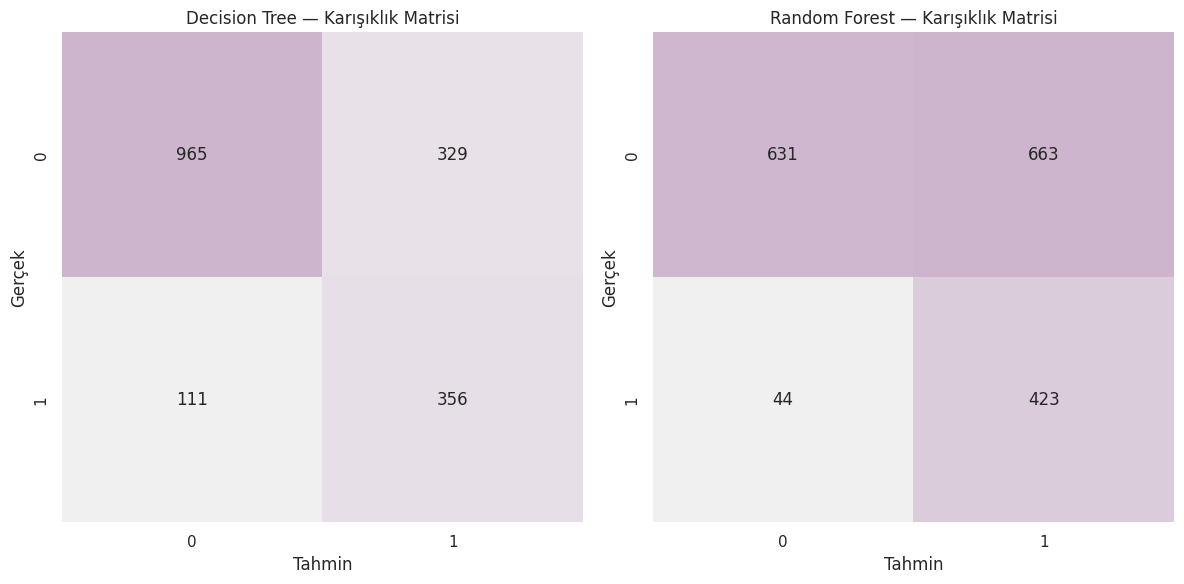

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (ad, pred) in zip(axes, [("Decision Tree", dt_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=sns.light_palette("#cdb5cd", as_cmap=True), ax=ax, cbar=False)
    ax.set_title(f"{ad} — Karışıklık Matrisi")
    ax.set_xlabel("Tahmin"); ax.set_ylabel("Gerçek")
plt.tight_layout(); plt.show()

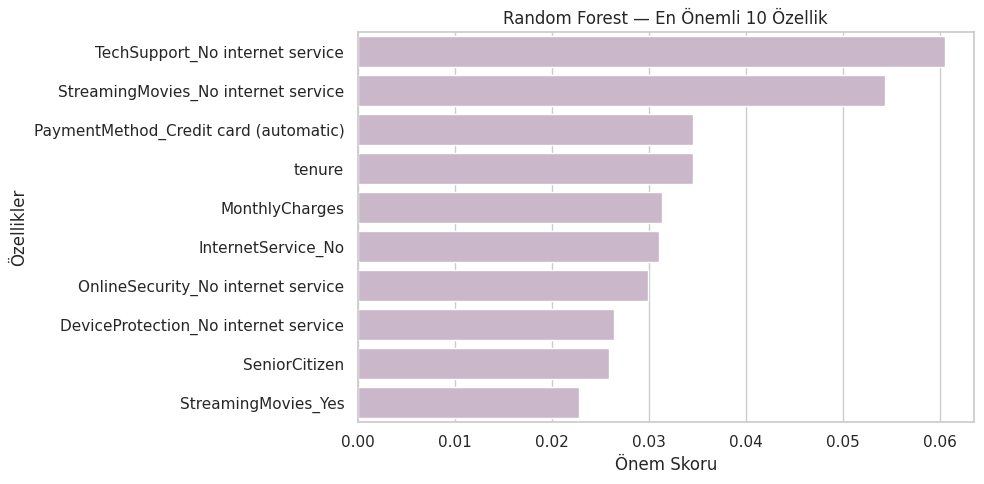

In [ ]:
onem = pd.Series(rf.feature_importances_, index=X.columns).nlargest(10)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=onem.values, y=onem.index, color="#cdb5cd", ax=ax)
ax.set_title("Random Forest — En Önemli 10 Özellik"); ax.set_xlabel("Önem Skoru"); ax.set_ylabel("Özellikler")
plt.tight_layout(); plt.show()

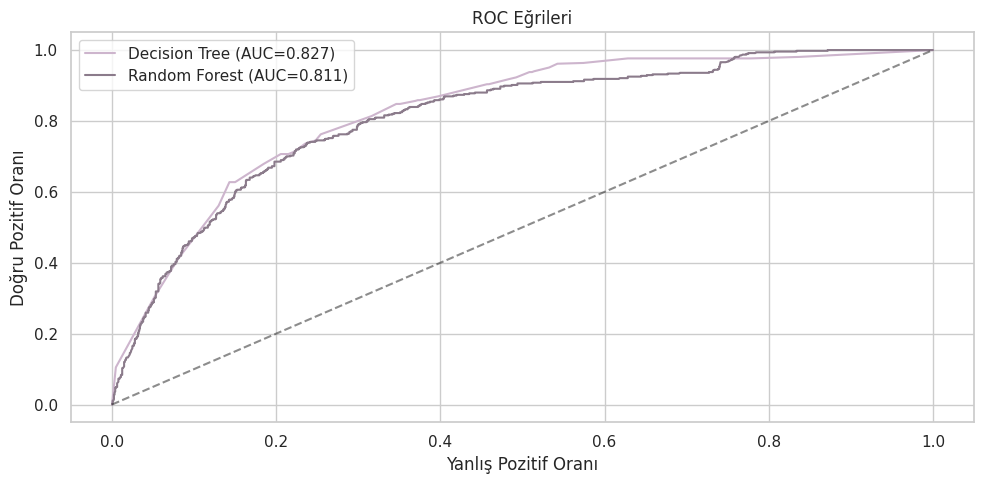

In [ ]:
if len(np.unique(y_te)) == 2:
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ["#cdb5cd", "#8b7b8b"]
    for i, (model, ad) in enumerate([(dt, "Decision Tree"), (rf, "Random Forest")]):
        proba = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_te, proba)
        ax.plot(fpr, tpr, label=f"{ad} (AUC={roc_auc_score(y_te, proba):.3f})", color=colors[i])
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_title("ROC Eğrileri")
    ax.set_xlabel("Yanlış Pozitif Oranı"); ax.set_ylabel("Doğru Pozitif Oranı")
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print("Çok sınıflı problem: ROC eğrisi atlandı.")

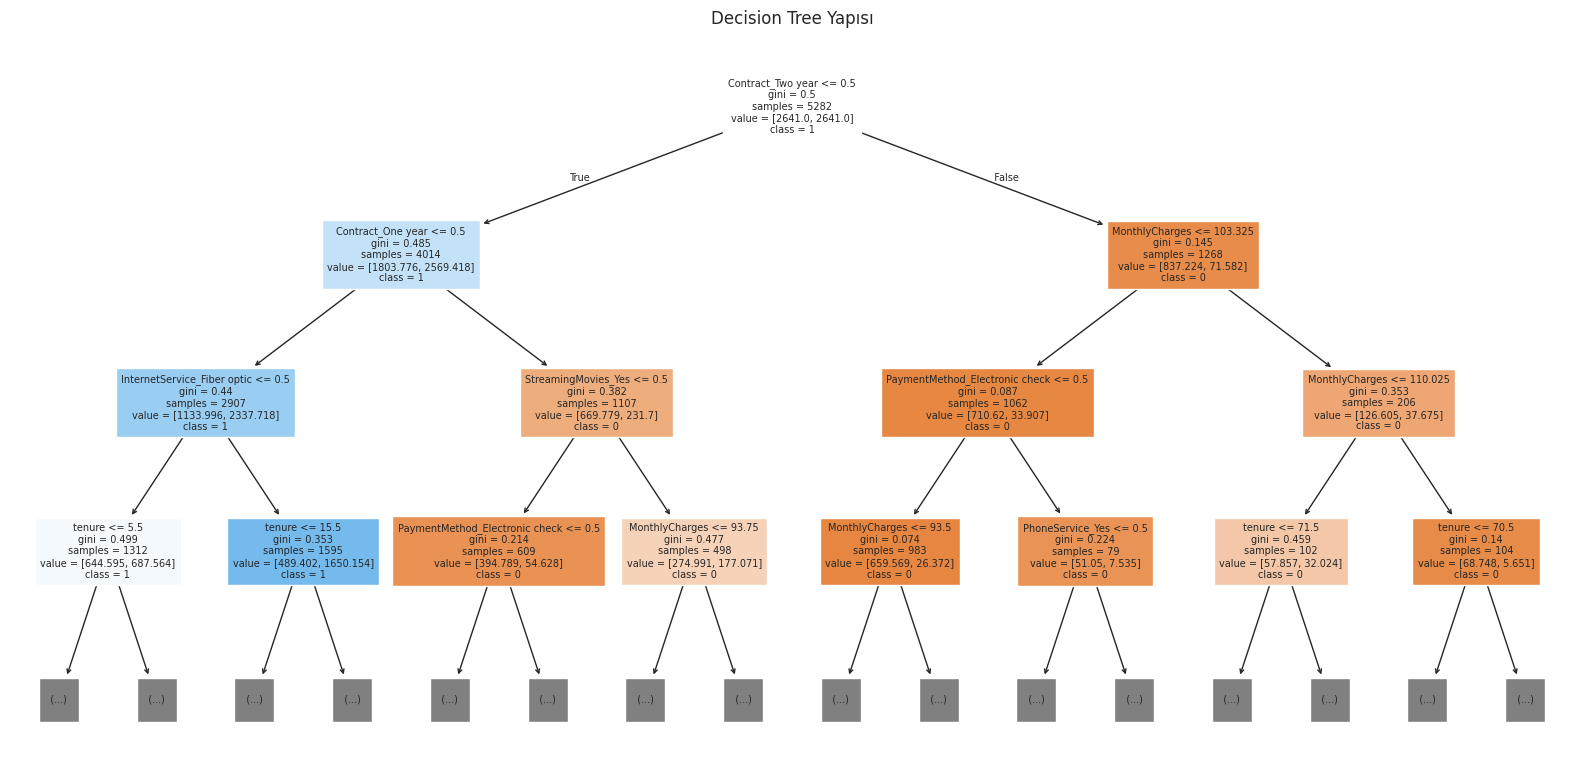

In [ ]:
fig,ax = plt.subplots(figsize=(16,8))
plot_tree(dt,max_depth=3, feature_names = list(X.columns), filled=True,
          fontsize=7,ax=ax, class_names=[str(cl) for cl in np.unique(y_te)])
ax.set_title("Decision Tree Yapısı")
plt.tight_layout(); plt.show()

In [ ]:
kazanan= tablo["F1 Skoru"].idxmax()
rapor = (
    f"Karar ağacı modeli test setinde % {dt_m['Doğruluk (Accuracy)']*100:.1f} doğruluk"
    f"(F1{dt_m['F1 Skoru']:.3f}), rastgele orman modeli ise"
    f" %{rf_m['Doğruluk (Accuracy)']*100:.1f} doğruluk (F1{rf_m['F1 Skoru']:.3f})"
    f" elde etmiştir. 5-katlı çapraz doğrulamada ortalama doğruluk sırasıyla "
    f"{dt_m['CV Ortalama']:.3f} (SS = {dt_m['CV Std']:.3f}) ve "
    f"{rf_m['CV Ortalama']:.3f} (SS = {rf_m['CV Std']:.3f}) olarak bulunmuştur."
    f"Genel performans açısından {kazanan} modeli daha başarılıdır."
)
print(rapor)

Karar ağacı modeli test setinde % 75.0 doğruluk(F10.762), rastgele orman modeli ise %59.9 doğruluk (F10.615) elde etmiştir. 5-katlı çapraz doğrulamada ortalama doğruluk sırasıyla 0.723 (SS = 0.015) ve 0.688 (SS = 0.018) olarak bulunmuştur.Genel performans açısından Decision Tree modeli daha başarılıdır.
